In [1]:
import scanpy as sc
import numpy as np 
import pandas as pd 
import anndata as ad
from glob import glob
from tqdm import tqdm
from multiprocessing import Pool
import seaborn as sns
sc._settings.ScanpyConfig.n_jobs=48

# 0. Check the QC results and remove low quality sample.

# 800Gb memory size is required

# 1. Concat filtered scADT data

In [ ]:
files = glob('/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/*_ADT_filtered.h5ad')

In [ ]:
files[1:10]

In [ ]:
len(files)

In [ ]:
data_dic = {}
for i in tqdm(files):
    sample_name = i.split('/')[-1].split('.')[0]
    adata = sc.read_h5ad(i)
    data_dic[sample_name] = adata

In [ ]:
adata = sc.concat(data_dic)

In [ ]:
adata

In [ ]:
adata.obs

In [ ]:
adata.write_h5ad("/home/liyanguo/MyImmuCell/02_Read_QC/scADT_filtered_MyImmuCell.h5ad",compression="gzip")

In [ ]:
print ('scADT filtered Done.')

In [ ]:
del adata,data_dic

# 2. Concat scRNA data of low UMI detection

In [ ]:
files = glob('/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/*_low_nCount_RNA.h5ad')

In [ ]:
files[1:10]

In [ ]:
len(files)

In [ ]:
chunk_size = 100
merged_adata = None

In [ ]:
for chunk_start in range(0,len(files),chunk_size):
    data_dic = {}
    chunk_files = files[chunk_start:chunk_start+chunk_size]
    
    #read chunk
    for i in tqdm(chunk_files):
        sample_name = i.split('/')[-1].split('.')[0]
        adata = sc.read_h5ad(i)
        data_dic[sample_name] = adata
    chunk_adata = sc.concat(data_dic,join='outer')
    del data_dic
    
    if merged_adata is None:
            merged_adata = chunk_adata
    else:
        merged_adata = sc.concat([merged_adata,chunk_adata],join='outer')
    del chunk_adata
print ('Read chunk done.')

In [ ]:
merged_adata

In [ ]:
merged_adata.obs

In [ ]:
merged_adata.write_h5ad("/home/liyanguo/MyImmuCell/02_Read_QC/scRNA_MyImmuCell_low_nCount_RNA.h5ad",compression="gzip")

In [ ]:
print ('scRNA Done.')

In [ ]:
del merged_adata

# 3. Concat scRNA data of high UMI detection

In [4]:
files = glob('/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/*_high_nCount_RNA.h5ad')

In [5]:
files[1:10]

['/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0864_M_Rep2_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0878_Rep2_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0428_Rep2_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0206_FT_Rep1_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0378_Rep2_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0144_Rep2_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0130_Rep1_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0097_Rep1_high_nCount_RNA.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_RNA_h5ad/D0899_Rep1_high_nCount_RNA.h5ad']

In [6]:
len(files)

1994

In [7]:
chunk_size = 100
merged_adata = None

In [8]:
for chunk_start in range(0,len(files),chunk_size):
    data_dic = {}
    chunk_files = files[chunk_start:chunk_start+chunk_size]
    
    #read chunk
    for i in tqdm(chunk_files):
        sample_name = i.split('/')[-1].split('.')[0]
        adata = sc.read_h5ad(i)
        data_dic[sample_name] = adata
    chunk_adata = sc.concat(data_dic,join='outer')
    del data_dic
    
    if merged_adata is None:
            merged_adata = chunk_adata
    else:
        merged_adata = sc.concat([merged_adata,chunk_adata],join='outer')
    del chunk_adata
print ('Read chunk done.')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [01:15<00:00,  1.25it/s]


Read chunk done.


In [9]:
merged_adata

AnnData object with n_obs × n_vars = 32707953 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class'

In [10]:
merged_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,SampleID,DonorID,percent_mito,percent_ribo,percent_mito_ribo,log10GenesPerUMI,percent_top50,...,Immune_All_Low,Adult_Human_Blood,Adult_Human_Bone_marrow,percent.mt,predicted.celltype.l2.score,predicted.celltype.l2,predicted.celltype.l1.score,predicted.celltype.l1,mapping.score,scDblFinder.class
D0589_Rep1_CACTTCGA_TATCAGCA_TAGGATGA,CACTTCGA,28279.0,3968,D0589_Rep1,D0589,2.263163,10.258496,12.521659,0.808402,62.194561,...,Plasma cells,Plasma cells,Plasma cells,2.263163,1.000000,Plasma,1.000000,other,0.995269,singlet
D0589_Rep1_AGGCTAAC_AAGGACAC_GCGAGTAA,AGGCTAAC,27629.0,5174,D0589_Rep1,D0589,7.148286,13.167324,20.315610,0.836190,29.400268,...,Plasma cells,Plasma cells,Plasma cells,7.148286,0.985943,Plasma,0.985943,other,0.941446,singlet
D0589_Rep1_AAGACGGA_CAATGGAA_CGAACTTA,AAGACGGA,27067.0,4052,D0589_Rep1,D0589,2.017217,11.079913,13.097129,0.813924,56.895851,...,Plasma cells,Plasma cells,Plasma cells,2.017217,1.000000,Plasma,1.000000,other,0.996315,singlet
D0589_Rep1_CTGGCATA_AGCACCTC_CACCTTAC,CTGGCATA,25552.0,3196,D0589_Rep1,D0589,1.690670,3.134784,4.825454,0.795160,73.630244,...,Plasma cells,Plasma cells,Plasma cells,1.690670,1.000000,Plasma,1.000000,other,0.994989,singlet
D0589_Rep1_GCGAGTAA_ACAGCAGA_GTGTTCTA,GCGAGTAA,24635.0,5171,D0589_Rep1,D0589,4.075502,15.437386,19.512888,0.845618,28.857317,...,Plasma cells,Plasma cells,Plasma cells,4.075502,0.927260,CD14 Mono,0.963154,Mono,0.351455,doublet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D0308_Rep1_AGTCACTA_AGAGTCAA_CAAGGAGC,AGTCACTA,452.0,81,D0308_Rep1,D0308,80.530973,1.106195,81.637168,0.718789,93.141593,...,Classical monocytes,Classical monocytes,Tcm/Naive helper T cells,80.530973,0.458234,CD4 Naive,0.515827,CD4 T,0.978443,singlet
D0308_Rep1_TATCAGCA_CACCTTAC_AGAGTCAA,TATCAGCA,439.0,130,D0308_Rep1,D0308,65.148064,5.011390,70.159453,0.799989,81.776765,...,Classical monocytes,Classical monocytes,Tcm/Naive helper T cells,65.148064,0.463134,CD4 Naive,0.523883,CD4 T,0.972064,singlet
D0308_Rep1_TGGCTTCA_CACCTTAC_GGTGCGAA,TGGCTTCA,438.0,155,D0308_Rep1,D0308,59.817352,2.968037,62.785388,0.829208,76.027397,...,Classical monocytes,Classical monocytes,Tcm/Naive helper T cells,59.817352,0.521254,CD4 Naive,0.614603,CD4 T,0.952603,singlet
D0308_Rep1_GTGTTCTA_AGAGTCAA_ACACAGAA,GTGTTCTA,422.0,94,D0308_Rep1,D0308,77.488152,0.947867,78.436019,0.751578,89.573460,...,Classical monocytes,Classical monocytes,Tcm/Naive helper T cells,77.488152,0.469197,CD4 Naive,0.530951,CD4 T,0.995911,singlet


In [11]:
merged_adata.write_h5ad("/home/liyanguo/MyImmuCell/02_Read_QC/scRNA_MyImmuCell_high_nCount_RNA.h5ad",compression="gzip")

In [12]:
print ('scRNA Done.')

scRNA Done.


In [13]:
del merged_adata

# 4. Concat and QC raw scADT data for dsb

In [2]:
files = glob('/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/*_ADT_raw.h5ad')

In [3]:
files[1:10]

['/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0856_Rep1_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0679_Rep2_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0508_Rep1_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0323_E_Rep2_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0864_E_Rep1_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0504_Rep1_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0570_Rep2_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0118_Rep1_ADT_raw.h5ad',
 '/home/liyanguo/MyImmuCell/02_Read_QC/MyImmuCell_ADT_h5ad/D0607_Rep1_ADT_raw.h5ad']

In [4]:
len(files)

1994

In [5]:
# Observation

In [6]:
adata = sc.read_h5ad(files[1])

In [7]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None,log1p=True)

In [8]:
adata.obs

,orig.ident,SampleID,DonorID,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts
D0856_Rep1_AAACATCG_AAACATCG_AAACATCG,AAACATCG,D0856_Rep1,D0856,9,2.302585,55.0,4.025352
D0856_Rep1_AACAACCA_AAACATCG_AAACATCG,AACAACCA,D0856_Rep1,D0856,2,1.098612,6.0,1.945910
D0856_Rep1_AACCGAGA_AAACATCG_AAACATCG,AACCGAGA,D0856_Rep1,D0856,2,1.098612,3.0,1.386294
D0856_Rep1_AACGCTTA_AAACATCG_AAACATCG,AACGCTTA,D0856_Rep1,D0856,2,1.098612,12.0,2.564949
D0856_Rep1_AACGTGAT_AAACATCG_AAACATCG,AACGTGAT,D0856_Rep1,D0856,16,2.833213,364.0,5.899898
...,...,...,...,...,...,...,...
D0856_Rep1_TGAAGAGA_TTCACGCA_TTCACGCA,TGAAGAGA,D0856_Rep1,D0856,2,1.098612,4.0,1.609438
D0856_Rep1_TGGAACAA_TTCACGCA_TTCACGCA,TGGAACAA,D0856_Rep1,D0856,4,1.609438,4.0,1.609438
D0856_Rep1_TGGCTTCA_TTCACGCA_TTCACGCA,TGGCTTCA,D0856_Rep1,D0856,3,1.386294,6.0,1.945910
D0856_Rep1_TGGTGGTA_TTCACGCA_TTCACGCA,TGGTGGTA,D0856_Rep1,D0856,4,1.609438,7.0,2.079442


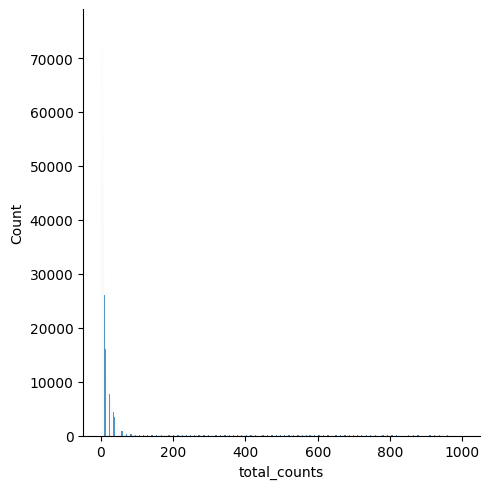

In [9]:
sns.displot(
    adata.obs.query("total_counts > 0 and total_counts < 1000").total_counts
)

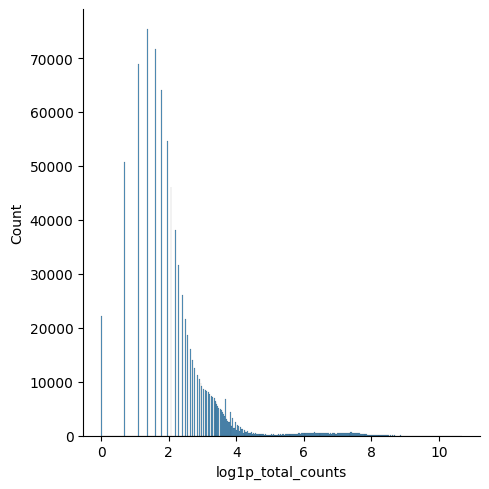

In [10]:
sns.displot(adata.obs.log1p_total_counts)

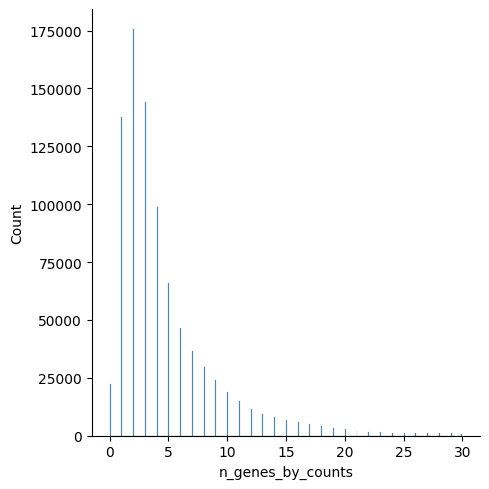

In [11]:
sns.displot(adata.obs.n_genes_by_counts)

In [12]:
data_dic = {}
for i in tqdm(files):
    sample_name = i.split('/')[-1].split('.')[0]
    adata = sc.read_h5ad(i)
    sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None,log1p=True)
    adata.obs["surely_empty_droplet"] = (adata.obs["total_counts"] < 40) & (adata.obs["total_counts"] > 0) & (adata.obs["n_genes_by_counts"] < 6) & (adata.obs["n_genes_by_counts"] > 0)
    adata.obs["surely_empty_droplet"].value_counts()
    adata = adata[adata.obs.surely_empty_droplet].copy()

    # random choice 25% for dsb, about 10 times the high-quality cell number
    np.random.seed(1)
    sample_idx = np.random.choice(adata.n_obs,
                                  size=adata.n_obs//4,
                                  replace=False)
    adata = adata[sample_idx, :].copy()
    data_dic[sample_name] = adata

100%|█████████████████████████████████████████████████████████████████████████████████████████| 1994/1994 [1:28:52<00:00,  2.67s/it]


In [13]:
adata = sc.concat(data_dic)

In [14]:
adata

AnnData object with n_obs × n_vars = 304755181 × 30
    obs: 'orig.ident', 'SampleID', 'DonorID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'surely_empty_droplet'

In [15]:
adata.obs

,orig.ident,SampleID,DonorID,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,surely_empty_droplet
D0641_Rep2_CCAGTTCA_AAGAGATC_GCCACATA,CCAGTTCA,D0641_Rep2,D0641,2,1.098612,4.0,1.609438,True
D0641_Rep2_ACAGCAGA_TGGTGGTA_TGGAACAA,ACAGCAGA,D0641_Rep2,D0641,3,1.386294,7.0,2.079442,True
D0641_Rep2_ACGTATCA_GACTAGTA_CAAGACTA,ACGTATCA,D0641_Rep2,D0641,2,1.098612,2.0,1.098612,True
D0641_Rep2_TTCACGCA_ACAAGCTA_ATGCCTAA,TTCACGCA,D0641_Rep2,D0641,2,1.098612,10.0,2.397895,True
D0641_Rep2_AAGAGATC_CGAACTTA_TGGCTTCA,AAGAGATC,D0641_Rep2,D0641,1,0.693147,1.0,0.693147,True
...,...,...,...,...,...,...,...,...
D0515_Rep2_ATTGAGGA_GATGAATC_GATAGACA,ATTGAGGA,D0515_Rep2,D0515,1,0.693147,1.0,0.693147,True
D0515_Rep2_GGTGCGAA_GTCGTAGA_AATGTTGC,GGTGCGAA,D0515_Rep2,D0515,1,0.693147,1.0,0.693147,True
D0515_Rep2_GAGCTGAA_GCGAGTAA_TGGTGGTA,GAGCTGAA,D0515_Rep2,D0515,1,0.693147,1.0,0.693147,True
D0515_Rep2_ACCTCCAA_CCATCCTC_ACCTCCAA,ACCTCCAA,D0515_Rep2,D0515,4,1.609438,6.0,1.945910,True


In [16]:
adata.write_h5ad("/home/liyanguo/MyImmuCell/02_Read_QC/scADT_raw_MyImmuCell.h5ad",compression="gzip")

In [17]:
print ('scADT raw Done.')

scADT raw Done.


In [18]:
del adata,data_dic